# How much of the population actually makes it to university?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv('education_pak.csv')





In [2]:
# 2. Extract Core Indicators for the Brain Drain Pipeline
# ENRR = Gross Enrollment Ratio
core_inds = [
    'SE.PRM.ENRR', # Primary Enrollment
    'SE.SEC.ENRR', # Secondary Enrollment
    'SE.TER.ENRR'  # Tertiary (University) Enrollment
]

short_names = {
    'SE.PRM.ENRR': '1. Primary Enrollment',
    'SE.SEC.ENRR': '2. Secondary Enrollment',
    'SE.TER.ENRR': '3. Tertiary (University) Enrollment'
}

df_filtered = df[df['Indicator Code'].isin(core_inds)].copy()
df_filtered['Indicator Name'] = df_filtered['Indicator Code'].map(short_names)

In [3]:
 #3. Reshape the Data
df_reshaped = df_filtered.pivot_table(index='Year', columns='Indicator Name', values='Value')

In [4]:


# 4. Feature Engineering: Create the "100 Student Cohort"
# Get the average of the most recent decade (2010 onwards) to represent modern trends
recent_data = df_reshaped.loc[2010:].mean()

# Normalize to a baseline of 100 students starting Primary School
primary_base = recent_data['1. Primary Enrollment']
funnel_data = (recent_data / primary_base) * 100


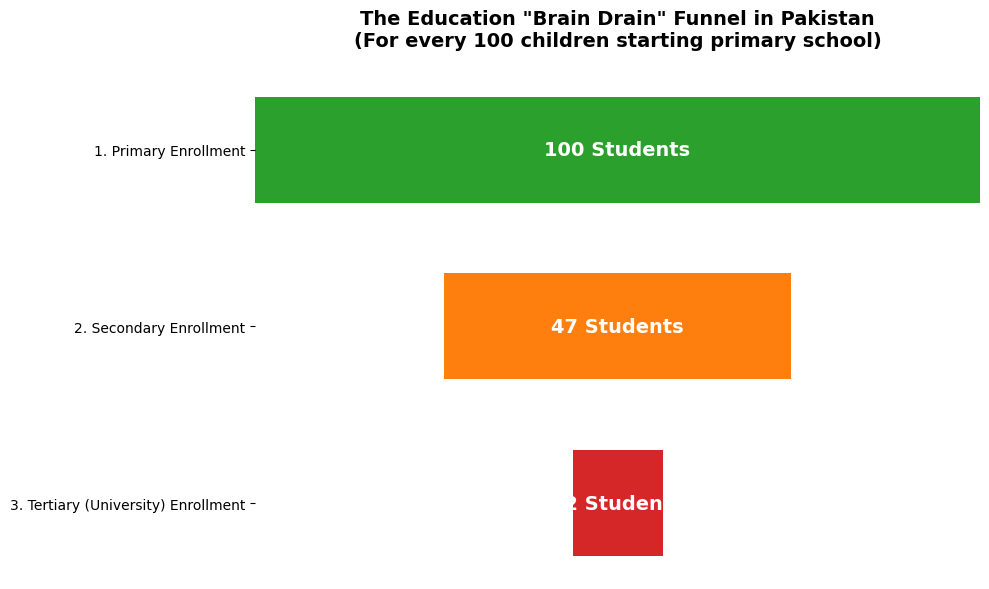

In [5]:

# 5. VISUALIZATION: The Funnel Chart
plt.figure(figsize=(10, 6))

# Define funnel stage colors
colors = ['#2ca02c', '#ff7f0e', '#d62728']
labels = funnel_data.index
values = funnel_data.values

# To make it look like a funnel, we draw horizontal bars and center them.
# The blank space on the left needs to be half of the missing value: (100 - value) / 2
left_positions = (100 - values) / 2

# We reverse the arrays [::-1] so Primary is at the top and Tertiary is at the bottom
plt.barh(labels[::-1], values[::-1], left=left_positions[::-1], color=colors[::-1], height=0.6)

# Add text labels right in the middle of the funnel
for i, (value, left) in enumerate(zip(values[::-1], left_positions[::-1])):
    plt.text(50, i, f"{int(value)} Students", ha='center', va='center', color='white', fontweight='bold', fontsize=14)

# Formatting the Chart
plt.title('The Education "Brain Drain" Funnel in Pakistan\n(For every 100 children starting primary school)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlim(0, 100)
plt.xticks([]) # Hide x-axis ticks to make it look like a clean graphic rather than a graph
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# 🧠 What this Project Reveals (Your Analysis)
(The output image generated by the code is visible at the top of our chat).

This visualization is incredibly powerful for a portfolio because it takes abstract percentages and turns them into a human-centric story.

The data reveals a severe systemic "Brain Drain" in the Pakistani education pipeline:

The Starting Line: We baseline our data at 100 students successfully entering Primary Education.

The First Major Drop: By the time that cohort reaches Secondary School age, the system loses more than half of them. Only 47 out of the original 100 students make it to secondary education.

The Final Cut: The transition to university is the steepest drop. Out of the 100 children who started primary school, only 12 make it into Tertiary education.